<center>
    
## <font color='maroon'>ASTR 21100/31200</font>
## <font color='maroon'>Computational techniques in astrophysics<br></font>

## <font color='maroon'>Numerical methods to calculate integrals<br></font>

</center>

### Instructor: 
Andrey Kravtsov (email: <tt>kravtsov@uchicago.edu</tt>, office: ERC 415)
Professor, Department of Astronomy & Astrophysics


### Teaching Assistants 

Rohan Gupta (rohangupta@uchicago.edu), 
Raul Gomez del Estal Teixeira (raulteixeira@uchicago.edu), 
Avery Metzcar (metzcara@uchicago.edu), 
Megan Zhao (yifanzyf@uchicago.edu)


In [1]:
import numpy as np 

# use jupyter "magic" command to tell it to embed plot into the notebook 
import matplotlib.pyplot as plt
%matplotlib inline

from codes.plotting import plot_prettier

plot_prettier()

### <font color='blue'>How far in distance can we currently observe with our technology?</font>

Nearest stars (excluding the Sun) are about a parsec away (parsec = 206265 AU).
<p>
    
<center>
<img width=700 src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/c1/Webb_Spectra_Reach_New_Milestone_in_Redshift_Frontier.png/1280px-Webb_Spectra_Reach_New_Milestone_in_Redshift_Frontier.png"></img>
</center>

<center>
    
### <font color='blue'>Typical steps involved in obtaining computational solution to a problem</font>
</center>
    

1. Definition of the problem that needs to solved.

2. Mathematical equations that describe the solution.

3. Algorithm to compute *approximate* solution on a computer (numerically). 

4. Implementation of the algorithm in code. 

5. Testing the code using a case with a known solution or comparing to another well-tested code. 

6. Applying the code to the problem at hand. 



### <font color='blue'>The difference between calculating regular integrals and solving ODEs</font>

Regular integrals, $f(x)$ depends just on $x$ and can be calculated for any $x\in[a,b]$: 

$$A = \int\limits_a^b f(x) dx.$$

ODEs, for example calculation of particle trajectory $x(t)$: 

$$x(t) = x_0 + \int\limits_{t_0}^t v_x(t) dt.$$

but $v_x(t)$ cannot be computed for any $t$ because $v_x(t)$ depends on $x(t)$, which we are trying to find out! Thus, both $x(t)$ and $v_x(t)$ are reconstructed step-by-step. 



It's as thought we would evaluate an integral with a trapezoidal method, but being able to compute only one trapezoid at a time, before being able to compute the area of the next trapezoid. 

<center>
    
Equations for the $x$ coordinate and $x$-component of velocity. 
$$\frac{dx}{dt}= v_x(t),$$
    
 
$$\frac{dv_x}{dt}= a_x(x,t) = -\frac{\partial\phi}{\partial x}.$$

We can separate differentials $dx$ and $dt$: $dx = v_x(t) dt$ and take integral from $t_0$ to $t$ of both sides: 

$$\int\limits_{t_0}^t dx = \int\limits_{t_0}^t v_x(t) dt.$$

The first integral contains just the full differential and is simply equal to $x(t) - x(t_0)$ so we can write
the equation for volution of the $x$ coordinate as

$$x(t) = x_0 + \int\limits_{t_0}^t v_x(t) dt.$$



### <font color='blue'>Error of a numerical scheme, truncation error</font>

$${\rm exact\ value}={\rm numerical\ estimate} + {\rm error}$$

For methods where we can use Taylor series to figure out how the error depends on the parameters of the numerical estimate: 

$${\rm exact\ value}={\rm numerical\ estimate} + \underbrace{\rm truncated\ Taylor\ terms}_{\rm truncation\ error}.$$

Knowledge of truncation terms can be exploited to construct more accurate schemes (Richardson's trick) and/or to estimate the error of the estimate. 

### <font color='blue'>Truncation error, Richardson's trick</font>

For numerical schemes the accuracy of which depends on the step size $h$

$${\rm exact\ value}={\rm numerical\ estimate} + e_1h + e_2h^2 + e_3h^3  +\mathcal{O}(h^4)$$

or for brevity: 

$$E=N_0(h) + e_1h + e_2h^2 + e_3h^3 + \mathcal{O}(h^4)$$


This can be numerical estimate of various quantities: derivative, integral, $x(t+\Delta t)$ given $x(t)$ in the ODE solution, etc. 

### <font color='blue'>Truncation error, Richardson's trick</font>

$$E=N_0(h/2) + e_1\frac{h}{2} + e_2\frac{h^2}{4} + e_3\frac{h^3}{8} +\mathcal{O}(h^4)$$

$$2E =  2N_0(h/2) + e_1h + e_2\frac{h^2}{2} + e_3\frac{h^3}{4}  +\mathcal{O}(h^4)$$

Subtracting from the above

$$E=N(h) + e_1h + e_2h^2 + e_3h^3 + \mathcal{O}(h^4)$$

we get: 

$$2E - E = E =  2N_0(h/2) - N(h) - \frac{1}{2}e_2h^2 - \frac{3}{4}e_3 h^3  +\mathcal{O}(h^4).$$

This gives as a new scheme $N_1(h) = 2N(h/2) - N(h)$ to estimate the quantity $E$ which has smaller truncation error because it has one less Taylor truncation term.

$$E =  N_1(h) - \frac{1}{2}e_2h^2 - \frac{3}{4}e_3 h^3  +\mathcal{O}(h^4).$$


$$E =  N_1(h/2) - \frac{1}{8}e_2h^2 - \frac{3}{32}e_3 h^3  +\mathcal{O}(h^4).$$

Multiplying the 2nd eq. by 4 and subtracting the first we get 

$$3E = 8 N_1(h/2) - N_1(h) + \frac{3}{8}e_3 h^3  +\mathcal{O}(h^4).$$

or 

$$E = \frac{8 N_1(h/2) - N_1(h)}{3} + \frac{3}{8}e_3 h^3  +\mathcal{O}(h^4) = N_2(h) + \frac{3}{8}e_3 h^3  +\mathcal{O}(h^4) $$.

where we have a new 3rd order accurate scheme for estimating $E$: 

$$N_2(h) = \frac{8 N_1(h/2) - N_1(h)}{3}$$

We can go on eliminating the terms. 

## <font color='blue'>Trapezoidal integration scheme</font>

The Euler-Maclaurin formula where $f_i = f(x_i)$ and $x_i = a + ih$: 
$$\int\limits_a^b f(x)dx = \underbrace{\frac{h}{2}\left[f(a)+f(b)\right] + h\sum\limits_{i=1}^{N-1}f_i}_{T(h)} + \frac{h^2}{12}\,\left[f^{\prime}(a)-f^{\prime}(b)\right] -  \frac{h^4}{720}\,\left[f^{\prime\prime\prime}(a)-f^{\prime\prime\prime}(b)\right]+\mathcal{O}(h^6),$$

where $T(h)$ is the integral estimate with the trapezoidal scheme using $N$ trapezoids or step $h=(b-a)/N$


It's a 2nd order scheme because leading truncation term is proportional to $h^2$.


Any function for which $f^{\prime}(a)-f^{\prime}(b)=0$, $f^{\prime\prime\prime}(a)-f^{\prime\prime\prime}(b)=0$, $f^{(5)}(a)-f^{(5)}(b)=0$, etc. will be evaluated exactly (to machine precision) by $T(h)$, regardless of $h$. 

If we can compute all these derivatives for $f(x)$ at $x=a$ and $x=b$ we can compute the integral precisely using $T(h)$ and extra Taylor terms in the Euler-Maclaurin formula. 

Richardson's trick for the trapezoidal scheme.

$$A = T(h) + e_2h^2 + e_4h^4 +\ldots$$  

$$A = T(h/2) + \frac{1}{4}e_2h^2 + \frac{1}{16} e_4h^4 +\ldots$$  

$$4A-A=3A = 4T(h/2) - T(h) -\frac{3}{4}e_4h^4 +\ldots$$

$$A = R_1(h) + \tilde{e}_4h^4 + \tilde{e}_6h^6 +\ldots$$ 

$$R_1(h) = \frac{4T(h/2) - T(h)}{3}$$


In [2]:
def trapzd(func, a, b, ntrap, *args):
    assert(ntrap > 0); assert(a < b)
          
    if ntrap == 1:
        return 0.5*(func(a, *args) + func(b, *args)) * (b-a)
    else: 
        hstep = (b - a) / ntrap
        # np.arange creates an array of values from 0 to nstep-1
        xd = a + np.arange(1,ntrap) * hstep 
        return (0.5*(func(a, *args) + func(b, *args)) + np.sum(func(xd, *args))) * hstep


In [3]:
def trapzd_h(func, a, b, h, *args):
    assert(h > 0); assert(a < b)
    ntrap = (b-a) / h
    # assert that [a,b] is divided by h into integer number of intervals
    if ntrap - int(ntrap) != 0.:
        raise ValueError(f'interval [{a:.3e}, {b:.3e}] must be exactly divisible by h = {h:.3e}')
    if abs(h - (b-a)) + 1. == 1.:
        return 0.5*(func(a, *args) + func(b, *args)) * (b-a)
    else: 
        hstep = (b - a) / ntrap
        # np.arange creates an array of values from 0 to nstep-1
        xd = a + np.arange(1,ntrap) * hstep 
        return (0.5*(func(a, *args) + func(b, *args)) + np.sum(func(xd, *args))) * hstep


In [4]:
def trapzd(func, a, b, ntrap, *args):
    """
    function implementing trapezoidal integration scheme using
    numpy vector operations
    
    Parameters:
        func: python function object
            function to integrate, must take numpy arrays as input
        a, b: floats
            limits of the integral
        ntrap: int, the number of trapezoids to use 
    
        args: parameters to be passed for func, if any 
    
    Returns:
        float: value of the estimated int^b_a f(x)dx
    """
    assert(ntrap > 0); assert(a < b)
          
    if ntrap == 1:
        return 0.5*(func(a, *args) + func(b, *args)) * (b-a)
    else: 
        hstep = (b - a) / ntrap
        # np.arange creates an array of values from 0 to nstep-1
        xd = a + np.arange(1,ntrap) * hstep 
        return (0.5*(func(a, *args) + func(b, *args)) + np.sum(func(xd, *args))) * hstep

In [5]:
a, b = 0., 1.
ntrap = 4
h = (b - a) / ntrap
func = np.exp

est1 = trapzd(func, a, b, ntrap)
print(est1, np.exp(1)-1)

est2 = trapzd_h(func, a, b, h)

print(est2, np.exp(1)-1)

1.7272219045575166 1.718281828459045
1.7272219045575166 1.718281828459045


## <font color='blue'>Romberg iterations implementing Richardson's trick</font>

Starting with $R_0(h) = T(h)$:

$$
R_{m+1}(h)=\frac{4^{m+1} R_{m}(h/2)-R_{m}(h)}{4^{m+1}-1}.
$$


## <font color='blue'>What's with the names???</font>

***Stigler's law of eponymy***, proposed by University of Chicago statistics professor Stephen Stigler in his 1980 publication Stigler’s law of eponymy, states that no scientific discovery is named after its original discoverer. 

So Romberg just rediscovered Richardson's trick in the context of integration and people started to call the integration method after him. A similar approach was rediscovered in the 1960s in the context of ODEs.

Other related example, $R_1(h)$ scheme is known as the *Simpson integration rule*  because the method is most often credited to the English mathematician Thomas Simpson (1710–1761). However, famous astronomer Johannes Kepler used similar formulas over 100 years prior



True to his own law, Stephen Stigler credits his eponymous "discovery" to the eminent sociologist Robert K. Merton.

## <font color='blue'>Romberg iteration $m=0$</font>


$$
R_1(h)=\frac{4 R_{0}(h/2)-R_{0}(h)}{3}.
$$


In [6]:
def r1(func, a, b, h, *args):
    return (4*trapzd_h(func, a, b, h/2, *args) - trapzd_h(func, a, b, h, *args)) / 3


## <font color='blue'>Romberg iteration $m=1$</font>


$$
R_2(h)=\frac{16 R_{1}(h/2)-R_{1}(h)}{15}.
$$


In [7]:
def r2(func, a, b, h, *args):
    return (16*r1(func, a, b, h/2, *args) - r1(func, a, b, h, *args)) / 15


## <font color='blue'>Romberg iteration $m=2$</font>


$$
R_3(h)=\frac{64 R_{2}(h/2)-R_{2}(h)}{63}.
$$


In [8]:
def r3(func, a, b, h, *args):
    return (64*r2(func, a, b, h/2, *args) - r2(func, a, b, h, *args)) / 63


In [9]:
a, b = 0., 1.
h = 0.5
func = np.exp
exact = np.exp(1) - 1

for i, int_est in enumerate([trapzd_h, r1, r2, r3]):
    est = int_est(func, a, b, h)
    ferr = (est - exact) / exact

    print(f'i = {i:d}, estimate = {est:.5e}, exact = {exact:.5e}, ferr = {ferr:.5e}')

i = 0, estimate = 1.75393e+00, exact = 1.71828e+00, ferr = 2.07470e-02
i = 1, estimate = 1.71832e+00, exact = 1.71828e+00, ferr = 2.15410e-05
i = 2, estimate = 1.71828e+00, exact = 1.71828e+00, ferr = 8.00765e-09
i = 3, estimate = 1.71828e+00, exact = 1.71828e+00, ferr = 7.81939e-13


## <font color='blue'>The equation for Romberg iterations is recursive</font>


Can me rewritten like this, more suitable for direct implementation in a recursive function. This is the same equation, but with relabeling $m\rightarrow m-1$.

$$
R_{m}(h)=\frac{4^{m} R_{m-1}(h/2)-R_{m-1}(h)}{4^{m}-1}.
$$


## <font color='blue'>Example of another (unrelated) recursion: Fibonacci numbers</font>

Fibonacci numbers for a sequence, in which each subsequent number is equal to the sum of two previous numbers. So $n$-th number in the sequence is defined by 


$$F(n) = 
\begin{cases} 
0 & \text{if } n = 1, \\
1 & \text{if } n = 2, \\
F(n-1) + F(n-2) & \text{if } n > 2.
\end{cases}$$

In [10]:
def fibonacci(n):
    assert(n > 0)
    if n == 1:
        return 0
    elif n == 2:
        return 1
    else:
        return fibonacci(n - 1) + fibonacci(n - 2)


In [14]:
def romberg_recursive(func, a, b, h, *args, m=0):
    """
    Recursive implementation of Romberg integration of 
    the integral int_a^b f(x)dx with initial stepsize h
    up to the Romberg iteration m
    
    Parameters:
        func: Python function name
        a, b: floats, integration limits, b>a
        h: float, step size, must divide [a, b] evenly
        args: tuple, parameters to be passed to func, if needed
            (can be empty)
        m: iteration number for which to compute R_m
    Returns:
        float: estimated value of the integral
    """
    if m == 0:
        return trapzd_h(func, a, b, h, *args)
    else:
        return (4**m * romberg_recursive(func,a,b,h/2,m = m-1) - romberg_recursive(func,a,b,h,m = m-1)) / (4**m - 1)
    return 0 


In [15]:
a, b = 0., 1.
h = 1.0
func = np.exp
exact = np.exp(1) - 1

for m  in range(11):
    est = romberg_recursive(func, a, b, h, m=m)
    ferr = (est - exact) / exact
    print(f'm = {m:d}, estimate = {est:.5e}, exact = {exact:.5e}, ferr = {ferr:.5e}')
    

m = 0, estimate = 1.85914e+00, exact = 1.71828e+00, ferr = 8.19767e-02
m = 1, estimate = 1.71886e+00, exact = 1.71828e+00, ferr = 3.37153e-04
m = 2, estimate = 1.71828e+00, exact = 1.71828e+00, ferr = 5.00189e-07
m = 3, estimate = 1.71828e+00, exact = 1.71828e+00, ferr = 1.95245e-10
m = 4, estimate = 1.71828e+00, exact = 1.71828e+00, ferr = 1.92545e-14
m = 5, estimate = 1.71828e+00, exact = 1.71828e+00, ferr = -1.29225e-16
m = 6, estimate = 1.71828e+00, exact = 1.71828e+00, ferr = 5.16899e-16
m = 7, estimate = 1.71828e+00, exact = 1.71828e+00, ferr = -2.58450e-16
m = 8, estimate = 1.71828e+00, exact = 1.71828e+00, ferr = -1.29225e-16
m = 9, estimate = 1.71828e+00, exact = 1.71828e+00, ferr = 0.00000e+00
m = 10, estimate = 1.71828e+00, exact = 1.71828e+00, ferr = 0.00000e+00


### <font color='blue'>Recursive calculation of the integral with $R_m(h)$ computes these under the hood:</font>

starting in the lower right corner and computing everything to the left. 

$$\begin{array}{cccccc}
R_0(h/2^m) &        & & & & \\
R_0(h/2^{m-1}) & R_1(h/2^{m-1}) & & & & \\
\vdots & \vdots & \vdots & \vdots & \ddots & \\
R_0(h/2^2) &R_1(h/2^2)  & \cdots & R_{m-2}(h/2^2) &  & \\
R_0(h/2) & R_1(h/2) & \cdots & R_{m-2}(h/2) & R_{m-1}(h/2) & \\
R_0(h) & R_1(h) & \cdots & R_{m-2}(h) & R_{m-1}(h) & R_m(h)
\end{array}$$


## <font color='blue'>Error control</font>

Stop computation when 
$$\vert R_{m-1}-R_m\vert<{\rm atol + rtol}\,R_m.$$

where ${\rm atol}$ and ${\rm rtol}$ are the absolute and relative (fractional) error tolerances that we want from the result. 

### <font color='blue'>Fractional (relative) error</font>
    
We always compute the fractional error either relative to the true value (if it's known) or relative to the more accurate estimate: 
    
    fractional error = (estimate - more_accurate_estimate) / more_accurate_estimate
   

## <font color='blue'>The most distant galaxies</font>

<center>
<img width=800 src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/c1/Webb_Spectra_Reach_New_Milestone_in_Redshift_Frontier.png/1280px-Webb_Spectra_Reach_New_Milestone_in_Redshift_Frontier.png"></img>

</center>

### <font color='blue'>Spectral shift $z=\Delta \lambda/\lambda$</font>
<center>
<img width=700 src="https://itu.physics.uiowa.edu/sites/itu.physics.uiowa.edu/files/2021-08/itu/redshift_deltalambda.png"></img>

</center>

<center>

<img width=600 src="https://itu.physics.uiowa.edu/sites/itu.physics.uiowa.edu/files/2021-08/itu/redshift_galaxyspectra.png"></img>

</center>

### <font color='blue'>Distance to a galaxy with spectral shift $z$</font>

Let's use it to compute something useful like integral of the following function: 

$$d_L = \frac{c}{H_0} (1+z)\int\limits_0^z \frac{dx}{E(x)}.$$

where $E(x)=\sqrt{m(1+x)^3+ k(1+x)^2+e}$, where $a$, $b$, $c$ are constants. $c$ is the speed of light in km/s and $H_0$ is the "Hubble constant" in km/s/Mpc, $H_0\approx 70$, $m$ is dimensionless parameter characterizing mean density of matter in the Universe (usually denoted as $\Omega_0$, $e$ is the mean density of "dark energy" (usually denoted as $\Omega_\Lambda$).  


***Note!*** This is a simplified expression valid for the case: $k=1-m-e$. You will implement full calculation of $d_L$ in hw 3. 




In [65]:
def dl_func(x, a, b, c):
    return 1.0 / np.sqrt(a*(1.+x)**3 + b*(1.+x)**2 + c)


In [75]:
a, b, c = 0.3, 0., 0.7
args = [a, b, c]
clight = 2.99792458e5 # speed of light in km/s
H0 = 70 # Hubble constant in km/s/Mpc

z = 13.2
nsteps = 1000000
d_l = clight / H0 * (1+z) * romberg_recursive(dl_func, 0., z, z, *args, m=5)

print(f'distance to the galaxy at z = {z:.2f} is d = {d_l/1e3:.2f} Gigaparsec')


One Megaparsec is million parsecs. One Gigaparsec is 1000 Megaparsecs or billion parsecs. 

One parsec is the distance light travels in about $\approx 3.24$ years. For a star at 1 parsec distance the apparent location on the sky will change by 1 second of arc when the Earth moves around the Sun in 6 months time due to change of the location from which we view it (the parallax effect).  

How can we check this calculation if we don't know the exact answer?  We can compare to the calculation by a similar function implemented by someone we'd trust. 

<a href="https://www.astropy.org/">Astropy</a> package has a <a href="https://docs.astropy.org/en/stable/_modules/astropy/cosmology/core.html#FLRW">cosmology sub-package</a>, which has many useful functions, including one that computes distance $d_L$.

In [67]:
from astropy.cosmology import LambdaCDM
import astropy.units as u

def d_l_astropy(z, H0, Om0, OmL):
    cosmo = LambdaCDM(H0=H0, Om0=Om0, Ode0=OmL)
    return cosmo.luminosity_distance(z=z) / u.Mpc


In [76]:
Om0 = 0.3; OmL = 0.7; H0 = 70.

d_la = d_l_astropy(z, H0, Om0, OmL)
print(f'distance Romberg = {d_l:.5f} Mpc; distance_astropy = {d_la:.5f} Mpc')


### <font color='blue'>Distance modulus of supernovae type Ia stars vs the shift of their spectral lines (redshift)</font>

Comparison of models to data shown in this plot  from <a href="https://ui.adsabs.harvard.edu/abs/2012ApJ...746...85S/abstract">Suzuki et al. 2012</a>, which uses many observational samples of <a href="https://en.wikipedia.org/wiki/Type_Ia_supernova">type Ia supernovae</a>, allows us to learn about the contents of our Universe.

<br>
<center><img width=800 src="https://astro.uchicago.edu/~andrey/classes/a211/img/suzuki_etal12_hubble_diagram.png"></img></center>

### <font color='blue'>The distance modulus</font>

The *distance modulus* - the difference of the observed *apparent magnitude* $m$ and *absolute magnitude* $M$ is a function of distance $d_L$ to the object (see [Sections 8.1.1-8.1.3](https://astro.uchicago.edu/~andrey/classes/a211w24/html/appendix/astro.html#magnitudes) of the notes): 

$$\mu = m - M = 5\log_{10}d_L + 25.$$

$$m = M + 5\log_{10}d_L + 25.$$


where $d_L$ is in Megaparsecs. Let's assume SN Ia are approximate "standard candles so that they all have the same $M\approx\rm const$. $M$ needs to be specified as part of the model.
    
Now we can compute $d_L$ for theoretical model with a given values of its parameters $H_0$, $\Omega_0$, $\Omega_\Lambda$  and compare it to observed $\mu_{\rm SNIa}=m-M$ of supernovae type Ia, as a function of spectral redshift $z$. 

### Supernovae type Ia sample

The data set is from the study of <a href="https://ui.adsabs.harvard.edu/abs/2014A%26A...568A..22B/abstract">Betoule et al. (2014)</a> and can also be downloaded <a href="http://supernovae.in2p3.fr/sdss_snls_jla/ReadMe.html">here</a>.

In [40]:
def read_jla_data(sn_list_name = None):
    """
    read in table with the JLA supernova type Ia sample
    
    Parameters
    ----------
    sn_list_name: str
        path/file name containing the JLA data table in ASCII format
        
    Returns
    -------
    zsn, msn, emsn - numpy float vectors containing 
                       zsn: SNIa redshifts in the CMB frame
                       msn, emsn: apparent B-magnitude and its errors
    """
    zsn, msn, emsn = np.loadtxt(sn_list_name, usecols=(1, 4, 5),  unpack=True)

    return zsn, msn, emsn


In [77]:
# you may need to change slash in the file name below on your system
# read vectors of redshifts, apparent magnitude in B-band, mB, and its uncertainty emB:
zsn, msn, emsn = read_jla_data(sn_list_name = 'https://astro.uchicago.edu/~andrey/classes/a211/data/jla_lcparams.txt')
nsn = np.size(zsn)
print("read sample of %d supernovae..."%(nsn))


read sample of 740 supernovae...


In [78]:
def mu_sn(z, Om0=1.0, OmL=0.0, H0=70):
    """
    compute mu_z for an input array of redshift values z
    """
    Omk = 1. - Om0 - OmL
    # these parameters correspond to mean matter density, mean geometric curvature, and mean "dark energy" density
    args = [Om0, Omk, OmL] 

    # compute distance for each z value in the grid
    d_lz = np.zeros_like(z)
    for i, zd in enumerate(z):
        d_lz[i] = clight / H0 * (1+zd) * romberg_recursive(dl_func, 0., zd, 0.1*zd, *args, m=5)

    # return distance modulus as a function of distance using theoretical expression
    return 5.0 * np.log10(d_lz) + 25.0


### Plot model $\mu=5\log_{10}d_L(z)+25$ vs observational $\mu_{\rm SNIa}$ for type Ia supernovae

In [79]:
from codes.plotting import plot_line_points 

# grid of redshift values 
zmin, zmax, nz = 0.01, 2, 100
z = np.linspace(zmin, zmax, nz)
Om0, OmL = 1., 0.
mu_model = mu_sn(z, Om0=Om0, OmL=OmL) 
Msn = -19.2


C:\Users\akrav\AppData\Local\Temp\ipykernel_125988\2158451000.py:15: RuntimeWarning: divide by zero encountered in log10
  return 5.0 * np.log10(d_lz) + 25.0


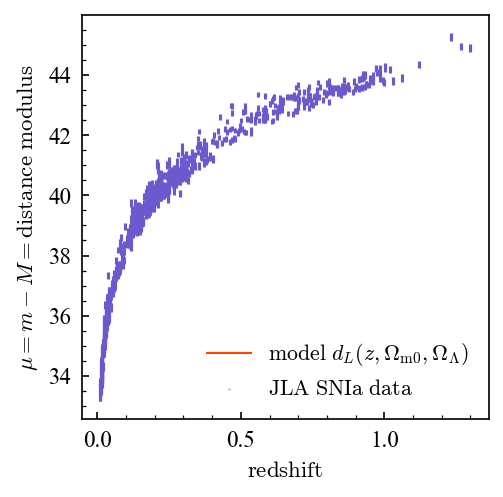

In [80]:
plot_line_points(z, mu_model, 
                 xlabel=r'$\rm redshift$', ylabel = r'$\mu=m-M=\rm distance\ modulus$',
                 col='orangered', pcol='slateblue', pmarker='.', psize=0.1, 
                 xp=zsn, yp=msn-Msn, eyp=emsn, legend=r'${\rm model}\ d_L(z,\Omega_{\rm m0},\Omega_\Lambda)$', 
                 plegend=r'$\rm JLA\ SNIa\ data$', points=True, figsize=3.5)


C:\Users\akrav\AppData\Local\Temp\ipykernel_125988\2158451000.py:15: RuntimeWarning: divide by zero encountered in log10
  return 5.0 * np.log10(d_lz) + 25.0


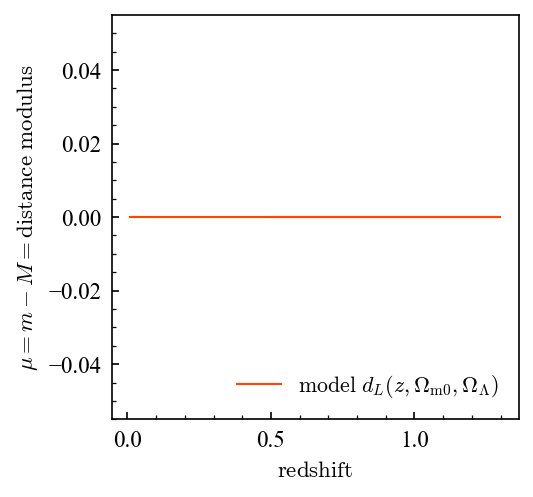

In [81]:
mu_models = mu_sn(zsn, Om0=Om0, OmL=OmL) 

plot_line_points(zsn, np.zeros_like(zsn), 
                 xlabel=r'$\rm redshift$', ylabel = r'$\mu=m-M=\rm distance\ modulus$',
                 col='orangered', pcol='slateblue', xp=zsn, yp=msn-Msn-mu_models, 
                 legend=r'${\rm model}\ d_L(z,\Omega_{\rm m0},\Omega_\Lambda)$', 
                 pmarker='.', psize=0.5,  points=True, figsize=3.5)


### <font color='blue'>Difficult integrals</font>

In [53]:
from codes.plotting import plot_line_points
plot_prettier(fontsize=12)

# read in function that will be used for this exercise
k, Pk = np.loadtxt('https://astro.uchicago.edu/~andrey/classes/a211/data/test_matterpower_logintk1000.dat', 
                   usecols=(0, 1),  unpack=True)

# their log10 values that will be used 
lk, lPk = np.log10(k), np.log10(Pk)

### <font color='blue'>Integrals of "spiky" functions</font>


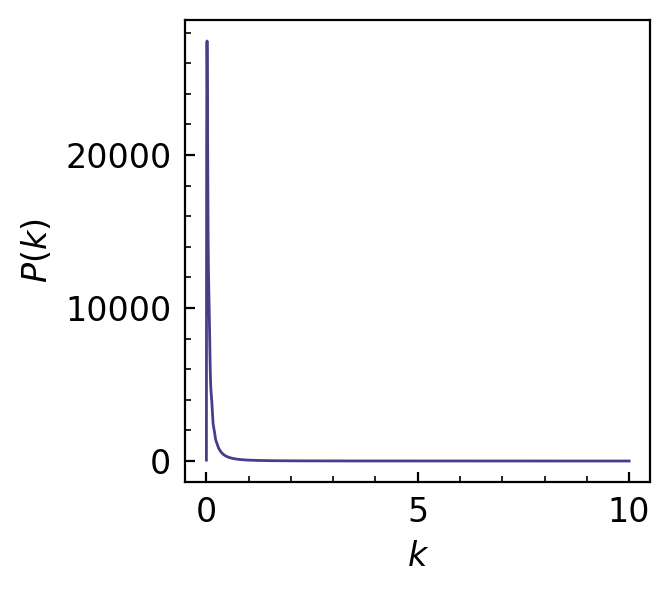

In [54]:
plot_line_points(k, Pk, xlabel=r'$k$', ylabel=r'$P(k)$', figsize=3)


In this case it is advantageous to integrate in $d\ln x=dx/x$ rather than in $dx$:

$$\int f(x) dx = \int f(x) x\, d\ln x.$$

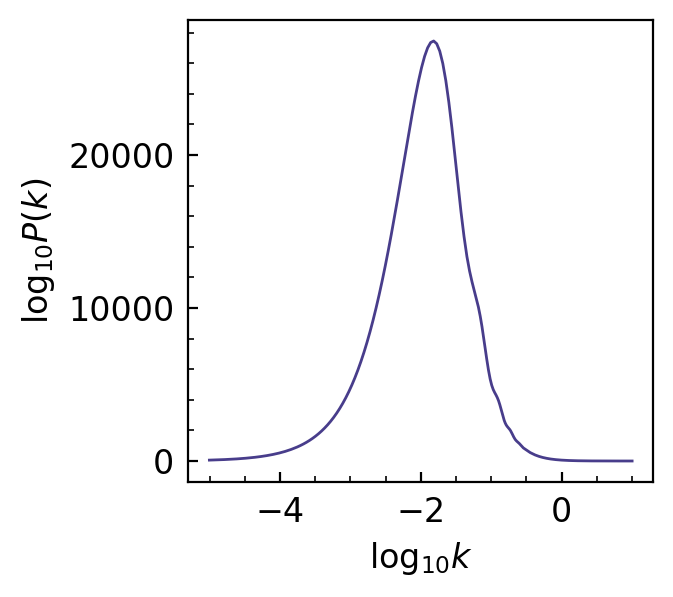

In [55]:
plot_line_points(lk, Pk, xlabel=r'$\log_{10} k$', ylabel=r'$\log_{10} P(k)$', figsize=3)


### <font color='blue'>Integrals of highly oscillatory functions</font>

Integrated function may oscillate with high/varying frequency on the integration  interval. Brute force estimate with Romberg may work in practice, although it won't be optimally efficient. [Sometimes](https://cosmocoffee.info/viewtopic.php?t=1313) brute force does not work. 


In [56]:
# plot example of a highly oscillatory function
def f_oscillatory(x, alpha):
    xi = alpha*x
    return np.sin(xi)/np.power(xi,2)

def plot_oscillatory():
    lx = np.linspace(-2, 2, 10000)
    x = 10.**lx

    alpha = 100.

    plt.figure(figsize=(3,3))
    plt.xlabel('$x$'); plt.ylabel(r'$\vert f(x)\vert $')
    plt.xscale('log'); plt.yscale('log')
    plt.plot(x, f_oscillatory(x, alpha), lw = 1., c='darkslateblue', 
                label=r'$f(x)=\frac{\sin \xi}{\xi^2},\ \ \xi=%.1f x$'%alpha)

    plt.legend(frameon=False, loc='upper right', fontsize=9)
    plt.show()


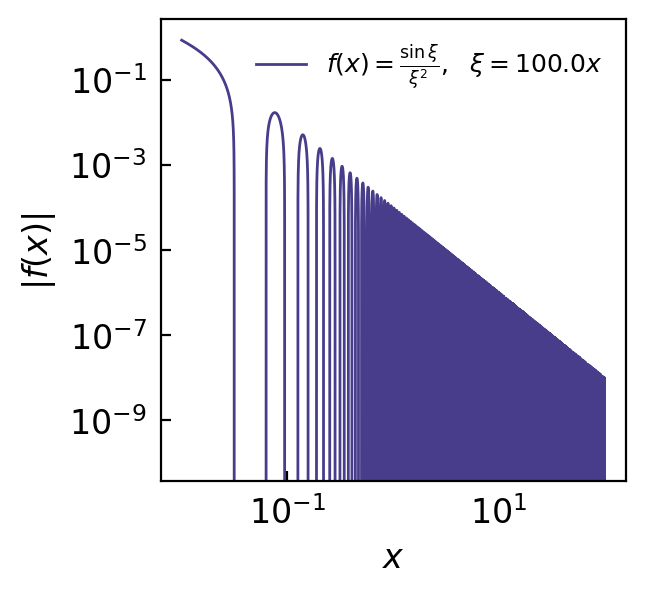

In [57]:
plot_oscillatory()


### <font color='blue'>Possible approaches</font>
    
* If integration results are suspect, examine how the function you are integrating looks like by graphing it. 


* If oscillations behave in a predictable way, split integral into a many individual integrals each over a single oscillation period or half-period. 
    
    
* Use adaptive integration by splitting integration interval into two and evaluating errors in each, keep splitting until error falls below a given acceptable tolerance level.
    
    
* In practice, solution will likely be specific to a given integral. Such case is an opportunity to be creative and think outside the box. The main thing is not to rely on a package function to take any integral you throw at it. 